# ANALISA 1 (14-4-2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
import re # Tambahan untuk membaca teks cerdas (Regex)

warnings.filterwarnings('ignore')

# 1. Load File Master untuk Mapping Jenis Alat (Dengan header=1)
df_master = pd.read_excel('cost & bbm 2022 sd 2025 HP & Type.xlsx', sheet_name='Sheet2', header=1)

# Membersihkan kolom nama di master agar pencocokan presisi
df_master['UNIT_MASTER'] = df_master['NAMA ALAT BERAT'].astype(str).str.strip().str.upper()

# Membuat kamus data menggunakan kolom 'ALAT BERAT'
mapping_type = dict(zip(df_master['UNIT_MASTER'], df_master['ALAT BERAT'].astype(str).str.strip().str.upper()))

print(f"Berhasil memuat mapping untuk {len(mapping_type)} unit dari file master.")

Berhasil memuat mapping untuk 245 unit dari file master.


In [2]:
def load_and_melt_excel(file_path):
    all_data = []
    xls = pd.read_excel(file_path, sheet_name=None, header=[0, 1, 2])
    for sheet_name, df in xls.items():
        df = df.set_index(df.columns[0]) 
        df.index.name = 'TANGGAL'
        df.columns = df.columns.droplevel(1) 
        df_stacked = df.stack(level=0).reset_index()
        df_stacked.rename(columns={'level_1': 'EQUIP NAME'}, inplace=True)
        all_data.append(df_stacked)
    df_final = pd.concat(all_data, ignore_index=True)
    df_final['TANGGAL'] = pd.to_datetime(df_final['TANGGAL'], format='%d-%m-%Y', errors='coerce')
    df_final = df_final.dropna(subset=['TANGGAL'])
    return df_final

# 1. Load data operasional
df_2024 = load_and_melt_excel('BBM AAB 2024 & Des 2025.xlsx')
df_2025 = load_and_melt_excel('BBM AAB.xlsx')
df_all = pd.concat([df_2024, df_2025], ignore_index=True)

# 2. Preprocessing Data Mentah (Delta HM & Anomali)
df_all = df_all.sort_values(by=['EQUIP NAME', 'TANGGAL'])
df_all['HM_Clean'] = pd.to_numeric(df_all['HM'], errors='coerce').replace(0, np.nan)
df_all['HM_Clean'] = df_all.groupby('EQUIP NAME')['HM_Clean'].ffill().fillna(0)
df_all['Delta_HM'] = df_all.groupby('EQUIP NAME')['HM_Clean'].diff().fillna(0)
df_all.loc[df_all['Delta_HM'] < 0, 'Delta_HM'] = 0
df_all.loc[df_all['Delta_HM'] > 100, 'Delta_HM'] = 0 

df_all['LITER_Clean'] = pd.to_numeric(df_all['LITER'], errors='coerce').fillna(0)

# =========================================================================
# 3. [BARU] TEMBOK FILTER: EXCLUDE ALAT MATI SURI & LITER NOL
# =========================================================================
# Hitung total pemakaian selama 24 bulan untuk setiap unit
akumulasi_unit = df_all.groupby('EQUIP NAME').agg({
    'Delta_HM': 'sum',
    'LITER_Clean': 'sum'
})

# SYARAT LULUS: Total HM harus lebih dari 0 DAN Total Liter harus lebih dari 0
unit_lulus_filter = akumulasi_unit[
    (akumulasi_unit['Delta_HM'] > 0) & 
    (akumulasi_unit['LITER_Clean'] > 0)
].index

# Eksekusi pembuangan unit yang tidak lulus (seperti SANY KUPP CAB TUAL)
df_all = df_all[df_all['EQUIP NAME'].isin(unit_lulus_filter)].copy()
# =========================================================================


# 4. Aturan Smart Matching (Integrasi File Master)
aturan_manual = {
    "FL RENTAL 01": "FL RENTAL 01 TIMIKA",
    "TOBATI (EX.FL KALMAR 32T)": "TOP LOADER KALMAR 35T/TOBATI",
    "L 8477 UUC (EX.L 9902 UR)": "L 9902 UR / S75",
    "WIND RIVER (EX.TL BOSS 42T)": "TOP LOADER BOSS",
    "L 8658 UK (EX.L 9582 UQ)": "L 9582 UQ"
}

import re 

def smart_mapping(raw_name, master_dict):
    raw_name = str(raw_name).strip().upper()
    
    if raw_name in aturan_manual:
        target = aturan_manual[raw_name]
        if target in master_dict: return master_dict[target]
        
    before_paren = raw_name.split('(')[0].strip()
    if before_paren in master_dict: return master_dict[before_paren]
        
    if raw_name in master_dict: return master_dict[raw_name]
        
    if "EX." in raw_name or "EX " in raw_name:
        try:
            after_ex = re.split(r'EX\s*\.?\s*', raw_name)[1].replace(')', '').strip()
            if after_ex in master_dict: return master_dict[after_ex]
        except IndexError:
            pass 
            
    return "TIDAK TERDAFTAR"

df_all['TYPE'] = df_all['EQUIP NAME'].apply(lambda x: smart_mapping(x, mapping_type))
df_all_raw = df_all.copy() # Simpan untuk analisa mismatch

# 5. Filter: Hanya menyertakan armada inti
alat_diizinkan = ['TRAILER', 'TRONTON', 'FORKLIFT', 'CRANE', 'TOP LOADER', 'SIDE LOADER', 'REACH STACKER']
df_all = df_all[df_all['TYPE'].isin(alat_diizinkan)].copy()

# 6. Agregasi Rata-Rata Makro (Metode 2 Tahap yang Benar)
unit_counts = df_all.groupby('TYPE')['EQUIP NAME'].nunique().to_dict()
df_all['TYPE_LABEL'] = df_all['TYPE'].apply(lambda x: f"{x} (n={unit_counts.get(x, 0)})")
df_all['TAHUN_BULAN'] = df_all['TANGGAL'].dt.to_period('M').astype(str)

# Tahap 1: Kumulasi per unit
df_unit_monthly = df_all.groupby(['TYPE_LABEL', 'TYPE', 'EQUIP NAME', 'TAHUN_BULAN'])['Delta_HM'].sum().reset_index()

# Tahap 2: Rata-rata per Jenis Alat
df_type_trend = df_unit_monthly.groupby(['TYPE_LABEL', 'TAHUN_BULAN'])['Delta_HM'].mean().reset_index()

total_unit_bersih = len(df_all['EQUIP NAME'].unique())
print(f"Preprocessing & Filtering Selesai! Tersisa {total_unit_bersih} unit alat operasional aktif.")

Preprocessing & Filtering Selesai! Tersisa 194 unit alat operasional aktif.


### Tren HM per Jenis Alat Berat

In [3]:
fig = px.line(df_type_trend, x='TAHUN_BULAN', y='Delta_HM', color='TYPE_LABEL', 
              title='Rata-Rata Tren HM per Jenis Alat Berat (Source: Master File)',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Rata-Rata HM Bulanan', 'TYPE_LABEL': 'Jenis Alat'},
              markers=True)

fig.update_layout(height=600, legend_title_text='Jenis Alat (Jumlah Unit)')
fig.show()

### Tren HM Reach Stacker

In [4]:
# --- AGREGASI BULANAN PER UNIT ---
# Menjumlahkan HM harian menjadi 1 titik total per bulan untuk setiap unit
df_unit_monthly = df_all.groupby(['TYPE', 'EQUIP NAME', 'TAHUN_BULAN'])['Delta_HM'].sum().reset_index()

# 1. Plot Khusus REACH STACKER
df_rs = df_unit_monthly[df_unit_monthly['TYPE'] == 'REACH STACKER']

fig_rs = px.line(df_rs, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: REACH STACKER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_rs.update_layout(height=600, legend_title_text='Nama Unit')
fig_rs.show()

### Tren HM Top Loader

In [5]:
# 2. Plot Khusus TOP LOADER
df_tl = df_unit_monthly[df_unit_monthly['TYPE'] == 'TOP LOADER']

fig_tl = px.line(df_tl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TOP LOADER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_tl.update_layout(height=600, legend_title_text='Nama Unit')
fig_tl.show()

### Tren HM Side Loader

In [6]:
# 3. Plot Khusus SIDE LOADER
df_sl = df_unit_monthly[df_unit_monthly['TYPE'] == 'SIDE LOADER']

fig_sl = px.line(df_sl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: SIDE LOADER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_sl.update_layout(height=600, legend_title_text='Nama Unit')
fig_sl.show()

### Tren HM Crane

In [7]:
# 4. Plot Khusus CRANE
df_crn = df_unit_monthly[df_unit_monthly['TYPE'] == 'CRANE']

fig_crn = px.line(df_crn, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: CRANE',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_crn.update_layout(height=600, legend_title_text='Nama Unit')
fig_crn.show()

### Tren HM Forklift

In [8]:
# 5. Plot Khusus FORKLIFT
df_fl = df_unit_monthly[df_unit_monthly['TYPE'] == 'FORKLIFT']

fig_fl = px.line(df_fl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: FORKLIFT',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_fl.update_layout(height=650, legend_title_text='Nama Unit')
fig_fl.show()

### Tren HM Trailer

In [9]:
# 6. Plot Khusus TRAILER
df_trl = df_unit_monthly[df_unit_monthly['TYPE'] == 'TRAILER']

fig_trl = px.line(df_trl, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TRAILER',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'})

fig_trl.update_layout(height=800, legend_title_text='Nama Unit')
fig_trl.show()

### Tren HM Tronton

In [10]:
# 7. Plot Khusus TRONTON
df_trn = df_unit_monthly[df_unit_monthly['TYPE'] == 'TRONTON']

fig_trn = px.line(df_trn, x='TAHUN_BULAN', y='Delta_HM', color='EQUIP NAME', 
              title='Detail Fluktuasi HM per Unit: TRONTON',
              labels={'TAHUN_BULAN': 'Bulan', 'Delta_HM': 'Total HM Bulanan'},
              markers=True)

fig_trn.update_layout(height=600, legend_title_text='Nama Unit')
fig_trn.show()

### Unit yang Masuk Analisa Tren

In [11]:
print("DAFTAR UNIT BERDASARKAN JENIS ALAT BERAT")

# Mengambil pasangan unik antara TYPE dan EQUIP NAME
df_unique_units = df_all[['TYPE', 'EQUIP NAME']].drop_duplicates().sort_values(by=['TYPE', 'EQUIP NAME'])

# Mengelompokkan nama alat berdasarkan jenisnya
grouped_units = df_unique_units.groupby('TYPE')['EQUIP NAME'].apply(list)

# Menampilkan hasilnya (ke samping)
for jenis, list_unit in grouped_units.items():
    print(f"\n[{jenis}] - Total: {len(list_unit)} unit")
    
    # Menggabungkan list nama unit dengan koma agar memanjang ke samping
    nama_unit_gabungan = ", ".join(list_unit)
    
    print(f"  -> {nama_unit_gabungan}")

DAFTAR UNIT BERDASARKAN JENIS ALAT BERAT

[CRANE] - Total: 6 unit
  -> CRANE LB 75/KANGGURU, CRANE LB 80T/LUCKY DOLPHIN, CRANE P&H 127 T/KOMODO, RG01, RG02, RG03

[FORKLIFT] - Total: 64 unit
  -> AKASIA, ALPINE, ATOZ, BANTENG 1, BANTENG 2, BANTENG 3, BANTENG 4, BENGKIRAI, BERNARD BEAR, CAMAR, CEMARA, CENDET, ELANG, FLAMINGO, FORKLIF MITS/KENANGA, GAJAH TUNGGAL, GARUDA, GATUT KACA, GIANT, GLATIK, HATORI, JALAK, JATAYU, KAKATUA, KALMAR 13, KALONG, KAMBOJA, KANTIL, KASUARI, KENARI, KOLIBRI, KUDA PUTIH, KUTILANG, MAGNETO, MANYAR, MATAHARI, MERAK, MERPATI, MURAI, PADI, PALEM, PENYU, PERKUTUT, PINUS, PRENJAK, RAFLESIA, RANDU, RANGER, ROBIN, SADEWA, SAKURA, SCORPION, SEMPATI, SERUNI, SOKA, TERATAI, TREMBESI, TULIB, ULIN, WALET, WARLOCK, WERKUDORO, WINDU, XAVIER

[REACH STACKER] - Total: 32 unit
  -> KALAMR5/KINGKONG 1, KALMAR 12, KALMAR 14, KALMAR 15, KALMAR 16, KALMAR 17, KALMAR 18, KALMAR 19, KALMAR 20, KALMAR 21, KALMAR 22, KALMAR 23, KALMAR 24, KALMAR 25, KALMAR 26, KALMAR 27, KALMAR 28, 

### Unit BBM AAB vs Master

In [ ]:
print("=== ANALISA MISMATCH DATA UNIT (Master vs Lapangan) ===")

# List unit yang berhasil dipetakan di BBM
mapped_in_bbm = df_all_raw[df_all_raw['TYPE'] != 'TIDAK TERDAFTAR']['EQUIP NAME'].unique()

def clean_name(name):
    return str(name).split('(')[0].strip().upper()

cleaned_bbm = set()
for name in df_all_raw['EQUIP NAME'].unique():
    # Cek apakah unit ini terpetakan lewat smart_mapping
    m_type = smart_mapping(name, mapping_type)
    if m_type != 'TIDAK TERDAFTAR':
        # Simpan nama master-nya jika terdeteksi
        res = clean_name(name)
        if "EX." in str(name).upper():
            try:
                ex_name = re.split(r'EX\s*\.?\s*', str(name).upper())[1].replace(')', '').strip()
                cleaned_bbm.add(ex_name)
            except: pass
        if name.strip().upper() in aturan_manual:
            cleaned_bbm.add(aturan_manual[name.strip().upper()])
        cleaned_bbm.add(res)

cleaned_master = set(df_master['UNIT_MASTER'].dropna().unique())
mismatch_ke_bbm = cleaned_master - cleaned_bbm

# --- OUTPUT SELISIH UNIT TRAILER & TRONTON ---
print("\n--- Unit Master yang Tidak Memiliki Aktivitas ---")
df_missing = df_master[df_master['UNIT_MASTER'].isin(mismatch_ke_bbm)]
for jenis, grup in df_missing.groupby('ALAT BERAT'):
    if jenis in ['TRAILER', 'TRONTON']:
        print(f"[{jenis}] - {len(grup)} unit:")
        for nama in grup['NAMA ALAT BERAT']:
            print(f"  -> {nama}")

=== ANALISA MISMATCH DATA UNIT (Master vs Lapangan) ===

--- Unit Master yang Tidak Memiliki Aktivitas ---
[TRAILER] - 41 unit:
  -> B 9157 ZJ
  -> B 9220 BL
  -> B 9224 BL
  -> B 9493 JA
  -> B 9494 JA
  -> B 9566 ZB
  -> B 9628 ZJ
  -> B 9974 KJ
  -> B 9976 KJ
  -> L 8007 UR / S73
  -> L 8016 UR
  -> L 8039 US / S74
  -> L 8050 US / S79
  -> L 8058 US / S78
  -> L 8115 US / S76
  -> L 8153 UO EX.L 9378 UN
  -> L 8159 US / S77
  -> L 8195 US
  -> L 8247 US
  -> L 8293 UQ
  -> L 8312 UQ
  -> L 8435 US / S80
  -> L 8814 UQ
  -> L 8819 UQ
  -> L 8854 UQ / S 68
  -> L 8856 UQ
  -> L 9025 UT
  -> L 9048 UT
  -> L 9049 UN
  -> L 9049 UR
  -> L 9052 UR
  -> L 9067 UQ
  -> L 9376 UN
  -> L 9561 UQ
  -> L 9583 UQ
  -> L 9902 UR / S75
  -> L 9958 UQ
  -> L9116UQ
  -> L9582UQ
  -> TN05
  -> TRAILER
[TRONTON] - 5 unit:
  -> L 8085 SK ( EX L 7287 TF )
  -> L 8609 UT ( EX L 7954 MU )
  -> L 8660 UN (EX. L7918MU)
  -> L 9628 US
  -> TRONTON PK 215


# ANALISA 2 (17-4-2026)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_squared_error
import warnings
import re
warnings.filterwarnings('ignore')

# 1. LOAD DATA
def load_and_melt_excel(file_path):
    all_data = []
    xls = pd.read_excel(file_path, sheet_name=None, header=[0, 1, 2])
    for sheet_name, df in xls.items():
        df = df.set_index(df.columns[0]) 
        df.index.name = 'TANGGAL'
        df.columns = df.columns.droplevel(1) 
        df_stacked = df.stack(level=0).reset_index()
        df_stacked.rename(columns={'level_1': 'EQUIP NAME'}, inplace=True)
        all_data.append(df_stacked)
    df_final = pd.concat(all_data, ignore_index=True)
    df_final['TANGGAL'] = pd.to_datetime(df_final['TANGGAL'], format='%d-%m-%Y', errors='coerce')
    df_final = df_final.dropna(subset=['TANGGAL'])
    return df_final

print("Mengekstrak data... (Proses ini mungkin memakan waktu beberapa detik)")
df_2024 = load_and_melt_excel('BBM AAB 2024 & Des 2025.xlsx')
df_2025 = load_and_melt_excel('BBM AAB.xlsx')
df_2026 = load_and_melt_excel('BBM AAB Jan-Mar 2026.xlsx') 

df_all = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)

# 2. KALKULASI HM HARIAN DENGAN RESET PER BULAN (Sesuai Standar Perusahaan)
df_all = df_all.sort_values(by=['EQUIP NAME', 'TANGGAL'])
df_all['HM_Clean'] = pd.to_numeric(df_all['HM'], errors='coerce').replace(0, np.nan)
df_all['HM_Clean'] = df_all.groupby('EQUIP NAME')['HM_Clean'].ffill().fillna(0)

# KOREKSI: Hitung selisih dengan mengelompokkan per bulan agar hari pertama direset menjadi 0 (Kehilangan 24 HM)
df_all['TAHUN_BULAN'] = df_all['TANGGAL'].dt.to_period('M')
df_all['Delta_HM'] = df_all.groupby(['EQUIP NAME', 'TAHUN_BULAN'])['HM_Clean'].diff().fillna(0)
df_all.loc[df_all['Delta_HM'] < 0, 'Delta_HM'] = 0
df_all.loc[df_all['Delta_HM'] > 100, 'Delta_HM'] = 0 

# 3. MAPPING JENIS ALAT
df_master = pd.read_excel('cost & bbm 2022 sd 2025 HP & Type.xlsx', sheet_name='Sheet2', header=1)
df_master['UNIT_MASTER'] = df_master['NAMA ALAT BERAT'].astype(str).str.strip().str.upper()
mapping_type = dict(zip(df_master['UNIT_MASTER'], df_master['ALAT BERAT'].astype(str).str.strip().str.upper()))

aturan_manual = {
    "FL RENTAL 01": "FL RENTAL 01 TIMIKA",
    "TOBATI (EX.FL KALMAR 32T)": "TOP LOADER KALMAR 35T/TOBATI",
    "L 8477 UUC (EX.L 9902 UR)": "L 9902 UR / S75",
    "WIND RIVER (EX.TL BOSS 42T)": "TOP LOADER BOSS",
    "L 8658 UK (EX.L 9582 UQ)": "L 9582 UQ"
}

def smart_mapping(raw_name, master_dict):
    raw_name = str(raw_name).strip().upper()
    if raw_name in aturan_manual:
        target = aturan_manual[raw_name]
        if target in master_dict: return master_dict[target]
    before_paren = raw_name.split('(')[0].strip()
    if before_paren in master_dict: return master_dict[before_paren]
    if raw_name in master_dict: return master_dict[raw_name]
    if "EX." in raw_name or "EX " in raw_name:
        try:
            after_ex = re.split(r'EX\s*\.?\s*', raw_name)[1].replace(')', '').strip()
            if after_ex in master_dict: return master_dict[after_ex]
        except IndexError:
            pass 
    return "TIDAK TERDAFTAR"

df_all['TYPE'] = df_all['EQUIP NAME'].apply(lambda x: smart_mapping(x, mapping_type))
print("Seluruh data berhasil diproses dengan kalkulasi HM aktual lapangan.")

Mengekstrak data... (Proses ini mungkin memakan waktu beberapa detik)
Seluruh data berhasil diproses dengan kalkulasi HM aktual lapangan.


In [15]:
print("Mencari kandidat target eksperimen Skripsi...")

df_train = df_all[df_all['TANGGAL'] <= '2025-12-31']

# A. Cari 3 Unit Tertinggi
avg_hm_unit = df_train.groupby('EQUIP NAME')['Delta_HM'].sum() / 24
top_3_units_series = avg_hm_unit.nlargest(3)

# B. Cari 3 Unit Terendah (Syarat: 12 Bulan Aktif Beruntun)
monthly_hm = df_train.groupby(['EQUIP NAME', df_train['TANGGAL'].dt.to_period('M')])['Delta_HM'].sum().unstack(fill_value=0)
consecutive_12 = (monthly_hm > 0).astype(int).rolling(window=12, axis=1).sum().max(axis=1) >= 12
eligible_lowest_units = consecutive_12[consecutive_12].index
bottom_3_units_series = avg_hm_unit.loc[eligible_lowest_units].nsmallest(3)

# C. Cari Jenis Tertinggi dan Terendah (Berdasarkan Rata-rata HM per Unit)
type_sums = df_train[df_train['TYPE'] != 'TIDAK TERDAFTAR'].groupby('TYPE')['Delta_HM'].sum()
type_counts = df_train[df_train['TYPE'] != 'TIDAK TERDAFTAR'].groupby('TYPE')['EQUIP NAME'].nunique()
avg_hm_type_per_unit = (type_sums / type_counts) / 24

top_1_type_series = avg_hm_type_per_unit.nlargest(1)
bottom_1_type_series = avg_hm_type_per_unit.nsmallest(1)

# =====================================================================
# TAMPILAN RINCIAN NILAI KANDIDAT (Sangat Bagus untuk Lampiran Skripsi)
# =====================================================================
print(f"\n{'='*60}")
print("[JUSTIFIKASI TARGET PER UNIT (Rata-Rata HM/Bulan)]")
print(f"{'-'*60}")
print("3 Unit Paling Tinggi (Top Performers):")
for unit, val in top_3_units_series.items():
    print(f"  -> {unit:.<35} : {val:.2f} HM")

print("\n3 Unit Paling Rendah (Memenuhi Syarat 12 Bulan Aktif):")
for unit, val in bottom_3_units_series.items():
    print(f"  -> {unit:.<35} : {val:.2f} HM")

print(f"\n{'='*60}")
print("[JUSTIFIKASI TARGET PER JENIS ALAT BERAT]")
print(f"{'-'*60}")
print("1 Jenis Rata-Rata Paling Besar (Beban Tertinggi):")
for tipe, val in top_1_type_series.items():
    print(f"  -> {tipe:.<35} : {val:.2f} HM/Unit/Bulan")

print("\n1 Jenis Rata-Rata Paling Kecil (Beban Terendah):")
for tipe, val in bottom_1_type_series.items():
    print(f"  -> {tipe:.<35} : {val:.2f} HM/Unit/Bulan")
print(f"{'='*60}\n")
# =====================================================================

# Mengonversi kembali menjadi format List agar bisa diproses oleh Block 4
top_3_units = top_3_units_series.index.tolist()
bottom_3_units = bottom_3_units_series.index.tolist()
top_1_type = top_1_type_series.index[0]
bottom_1_type = bottom_1_type_series.index[0]

Mencari kandidat target eksperimen Skripsi...

[JUSTIFIKASI TARGET PER UNIT (Rata-Rata HM/Bulan)]
------------------------------------------------------------
3 Unit Paling Tinggi (Top Performers):
  -> RG02............................... : 694.33 HM
  -> RG01............................... : 694.08 HM
  -> RG03............................... : 688.42 HM

3 Unit Paling Rendah (Memenuhi Syarat 12 Bulan Aktif):
  -> L 9103 NN EX. L 8781 LY............ : 11.53 HM
  -> TOP LOADER MITS/CENDRAWASIH........ : 17.62 HM
  -> L 8604 UK (EX.L 9620 US)........... : 18.10 HM

[JUSTIFIKASI TARGET PER JENIS ALAT BERAT]
------------------------------------------------------------
1 Jenis Rata-Rata Paling Besar (Beban Tertinggi):
  -> CRANE.............................. : 355.06 HM/Unit/Bulan

1 Jenis Rata-Rata Paling Kecil (Beban Terendah):
  -> TOP LOADER......................... : 30.89 HM/Unit/Bulan



In [26]:
def prep_timeseries(nama_target, is_type=False, freq='M'):
    if is_type:
        df_sub = df_all[df_all['TYPE'] == nama_target].copy()
    else:
        df_sub = df_all[df_all['EQUIP NAME'] == nama_target].copy()
        
    if freq == 'M':
        ts = df_sub.set_index('TANGGAL').resample('MS')['Delta_HM'].sum()
        idx = pd.date_range(start='2024-01-01', end='2026-03-01', freq='MS')
    else: # Weekly
        df_sub['TAHUN_MINGGU'] = df_sub['TANGGAL'].dt.to_period('W-MON')
        df_sub['Delta_HM_Mingguan'] = df_sub.groupby(['EQUIP NAME', 'TAHUN_MINGGU'])['HM_Clean'].diff().fillna(0)
        df_sub.loc[df_sub['Delta_HM_Mingguan'] < 0, 'Delta_HM_Mingguan'] = 0
        df_sub.loc[df_sub['Delta_HM_Mingguan'] > 100, 'Delta_HM_Mingguan'] = 0 
        ts = df_sub.set_index('TANGGAL').resample('W-MON')['Delta_HM_Mingguan'].sum()
        idx = pd.date_range(start='2024-01-01', end='2026-03-31', freq='W-MON')
        
    ts = ts.reindex(idx, fill_value=0)
    
    if is_type:
        if freq == 'M':
            active_units = df_sub[df_sub['Delta_HM'] > 0].set_index('TANGGAL').resample('MS')['EQUIP NAME'].nunique()
        else:
            active_units = df_sub[df_sub['Delta_HM_Mingguan'] > 0].set_index('TANGGAL').resample('W-MON')['EQUIP NAME'].nunique()
        active_units = active_units.reindex(idx, fill_value=1).replace(0, 1)
        ts = ts / active_units
    
    train = ts[ts.index <= '2025-12-31']
    test = ts[(ts.index >= '2026-01-01') & (ts.index <= '2026-03-31')]
    return train, test

def run_arima_vs_sarima(nama_target, is_type=False, freq='M', kategori_target=""):
    train, test = prep_timeseries(nama_target, is_type, freq)
    m_season = 12 if freq == 'M' else 52
    lbl_freq = "Bulanan" if freq == 'M' else "Mingguan"
    avg_aktual_2026 = test.mean() 
    
    print(f"[{lbl_freq}] Memproses {kategori_target}: {nama_target}")
    
    # 1. ARIMA
    model_arima = pm.auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore")
    pred_arima = np.maximum(0, model_arima.predict(n_periods=len(test)))
    rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
    
    # 2. SARIMA
    try:
        if m_season == 52:
            model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, 
                                         suppress_warnings=True, error_action="ignore",
                                         start_p=0, start_q=0, start_P=0, start_Q=0,
                                         max_p=1, max_q=1, max_P=1, max_Q=1, D=0)
        else:
            try:
                model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, suppress_warnings=True, error_action="ignore")
            except ValueError:
                model_sarima = pm.auto_arima(train, seasonal=True, m=m_season, stepwise=True, suppress_warnings=True, error_action="ignore", D=0)
        pred_sarima = np.maximum(0, model_sarima.predict(n_periods=len(test)))
        rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))
    except Exception as e:
        pred_sarima = np.zeros(len(test))
        rmse_sarima = np.nan
        
    # 3. PLOTTING
    plt.figure(figsize=(14, 5))
    lookback = 6 if freq == 'M' else 12 
    plt.plot(train.index[-lookback:], train.values[-lookback:], label='Train', marker='o', color='gray', linestyle=':')
    plt.plot(test.index, test.values, label='Aktual 2026', marker='s', color='green', linewidth=2)
    plt.plot(test.index, pred_arima.values, label=f'ARIMA (RMSE: {rmse_arima:.1f})', marker='^', linestyle='--', color='blue')
    
    if not np.isnan(rmse_sarima):
        plt.plot(test.index, pred_sarima.values, label=f'SARIMA (RMSE: {rmse_sarima:.1f})', marker='x', linestyle='--', color='red')
    
    # --- LOGIKA ANNOTATE ANTI-TUMPUK ---
    for i in range(len(test)):
        # Label Aktual (Selalu di atas)
        plt.annotate(f"{test.values[i]:.0f}", (test.index[i], test.values[i]), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontweight='bold', fontsize=9)
        
        if not np.isnan(rmse_sarima):
            # Cek jika tebakan ARIMA dan SARIMA sama persis (selisih < 0.5 HM)
            if abs(pred_arima.values[i] - pred_sarima.values[i]) < 0.5:
                # Tampilkan angka gabungan warna Ungu
                plt.annotate(f"A&S: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='purple', fontweight='bold', fontsize=9)
            else:
                # Jika beda, pisahkan A ke kiri bawah, S ke kanan bawah
                plt.annotate(f"A: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(-10,-15), ha='right', color='blue', fontsize=9)
                plt.annotate(f"S: {pred_sarima.values[i]:.0f}", (test.index[i], pred_sarima.values[i]), textcoords="offset points", xytext=(10,-15), ha='left', color='red', fontsize=9)
        else:
            # Jika SARIMA gagal, tampilkan A saja
            plt.annotate(f"A: {pred_arima.values[i]:.0f}", (test.index[i], pred_arima.values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='blue', fontsize=9)
            
    plt.title(f'[{lbl_freq}] {kategori_target} - {nama_target}', fontsize=14, fontweight='bold')
    plt.ylabel('Hour Meter (HM)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # 4. TABEL DATA
    from IPython.display import display
    df_compare = pd.DataFrame({
        'Aktual (HM)': test.values,
        'Prediksi_ARIMA': pred_arima.values,
        'Prediksi_SARIMA': pred_sarima.values if not np.isnan(rmse_sarima) else [np.nan]*len(test)
    }, index=test.index.strftime('%Y-%m-%d'))
    
    print(f"Rincian Tabel Prediksi {lbl_freq}")
    display(df_compare.round(1))
    print("\n")
    
    return {
        'Target': nama_target, 
        'Kategori': kategori_target, 
        'Frekuensi': lbl_freq, 
        'Rata_Aktual_2026': avg_aktual_2026,
        'RMSE_ARIMA': rmse_arima, 
        'RMSE_SARIMA': rmse_sarima
    }

DATA BULANAN (m=12)
[Bulanan] Memproses Unit Tertinggi: RG02


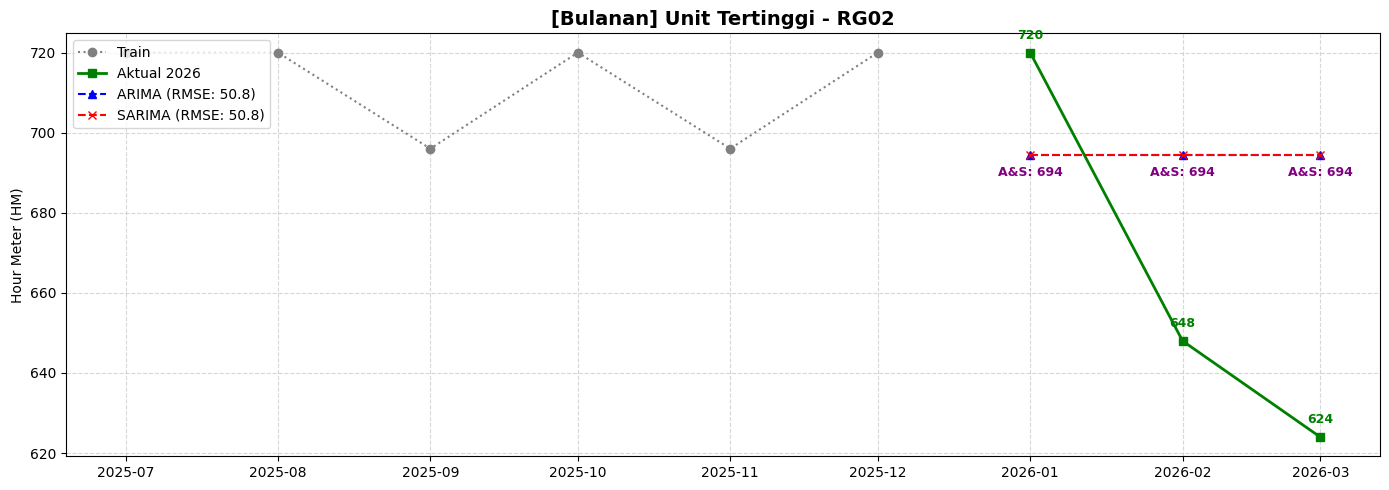

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,720.0,694.3,694.3
2026-02-01,648.0,694.3,694.3
2026-03-01,624.0,694.3,694.3




[Bulanan] Memproses Unit Tertinggi: RG01


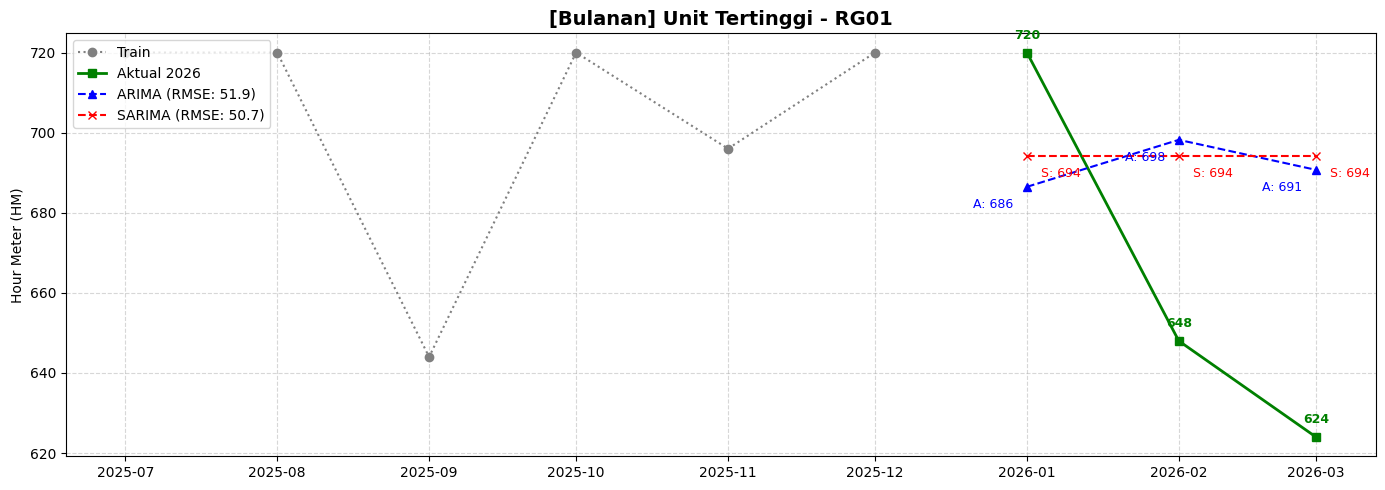

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,720.0,686.5,694.1
2026-02-01,648.0,698.2,694.1
2026-03-01,624.0,690.7,694.1




[Bulanan] Memproses Unit Tertinggi: RG03


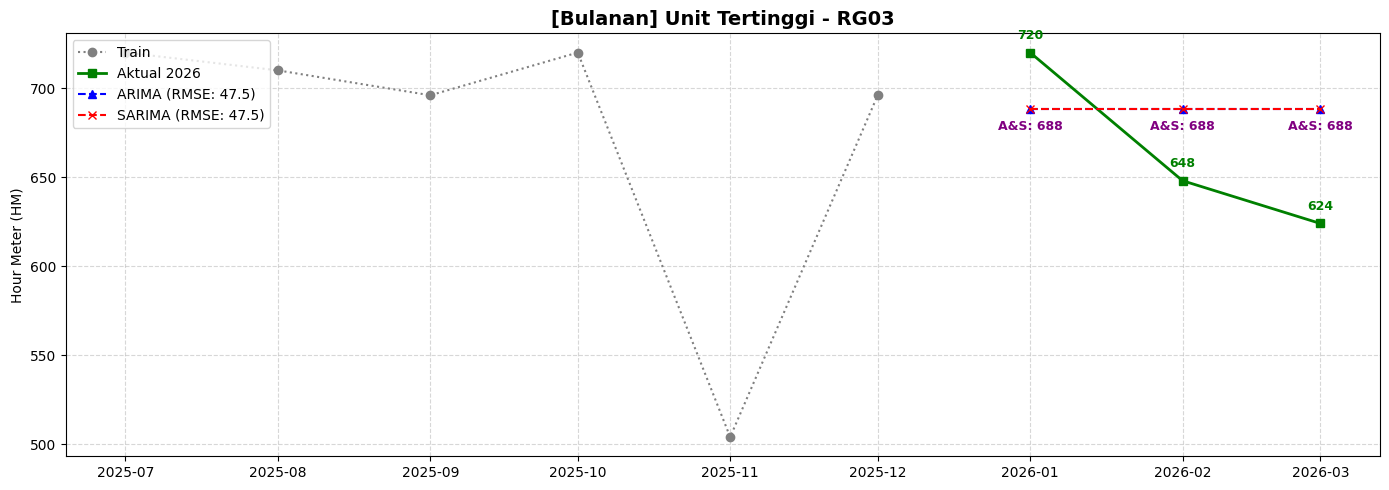

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,720.0,688.4,688.4
2026-02-01,648.0,688.4,688.4
2026-03-01,624.0,688.4,688.4




[Bulanan] Memproses Unit Terendah: L 9103 NN EX. L 8781 LY


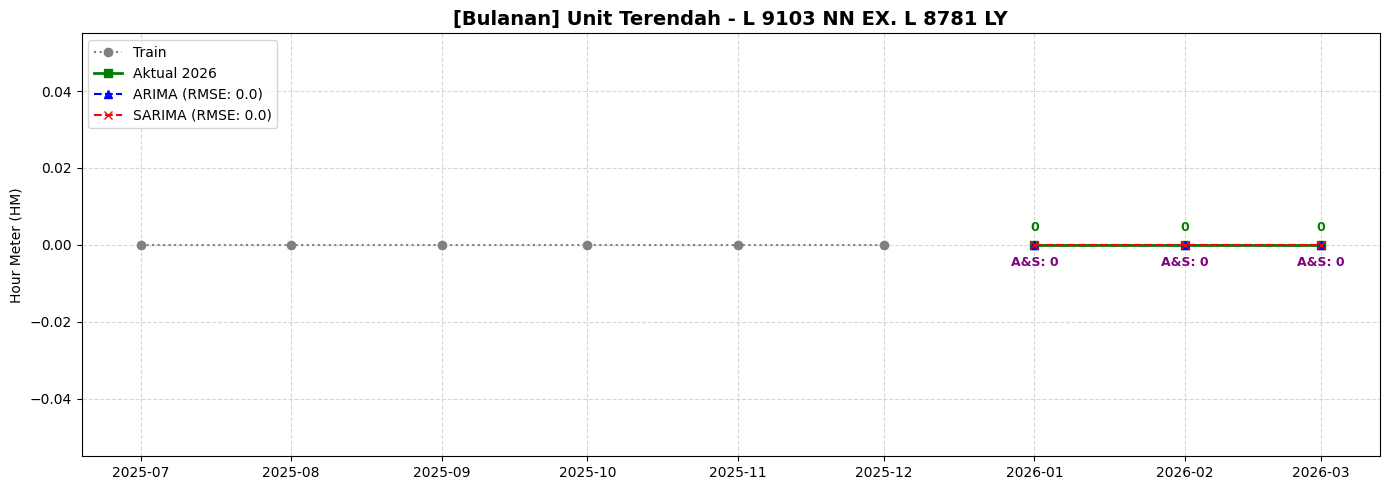

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,0.0,0.0,0.0
2026-02-01,0.0,0.0,0.0
2026-03-01,0.0,0.0,0.0




[Bulanan] Memproses Unit Terendah: TOP LOADER MITS/CENDRAWASIH


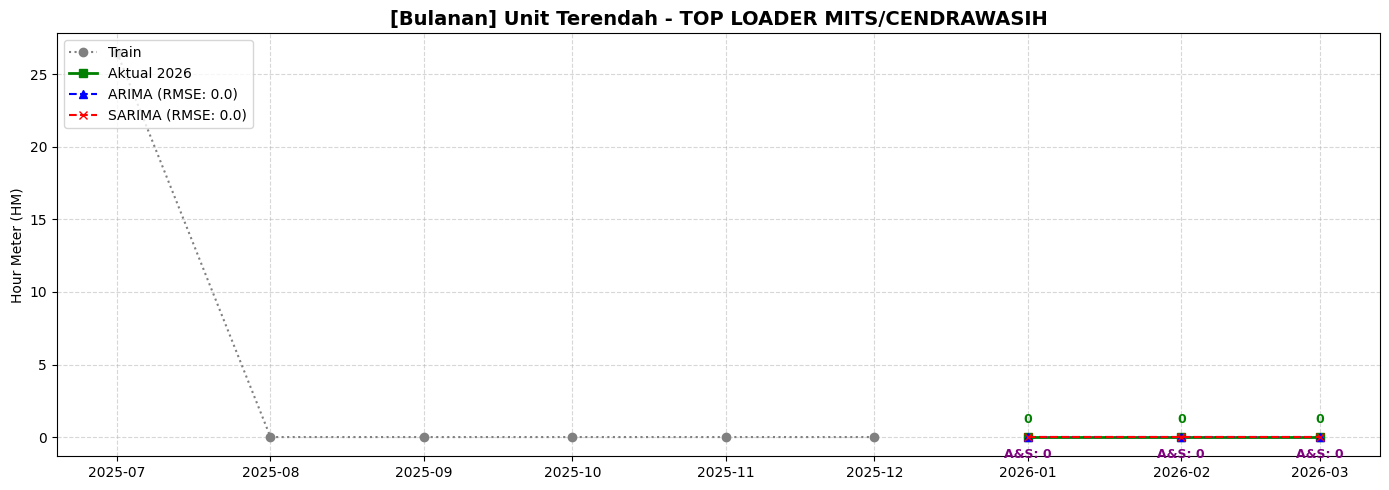

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,0.0,0.0,0.0
2026-02-01,0.0,0.0,0.0
2026-03-01,0.0,0.0,0.0




[Bulanan] Memproses Unit Terendah: L 8604 UK (EX.L 9620 US)


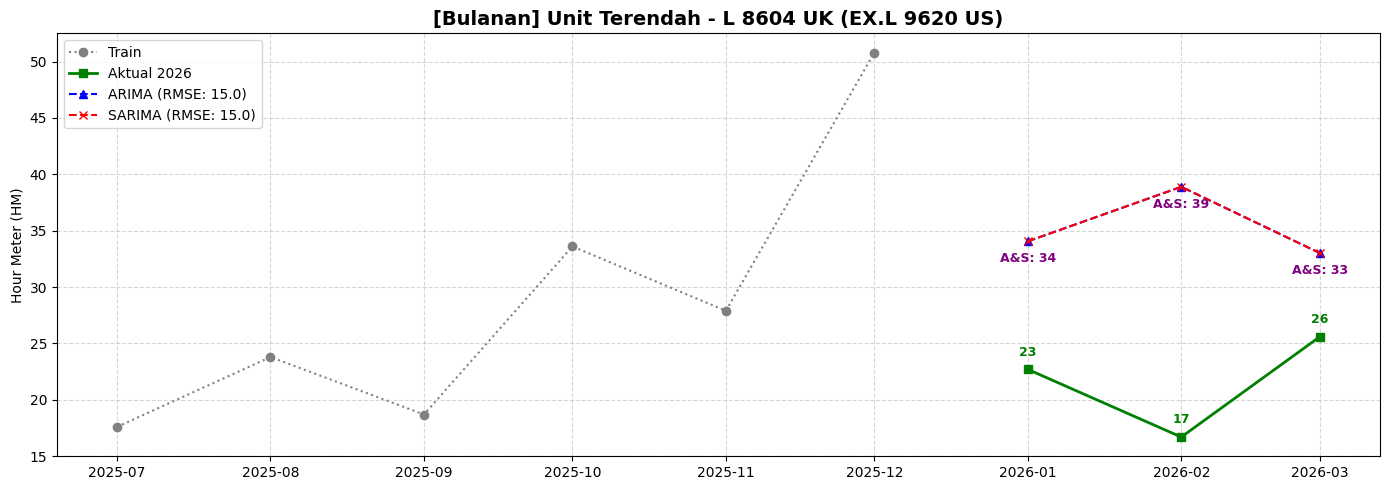

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,22.7,34.1,34.1
2026-02-01,16.7,38.9,38.9
2026-03-01,25.6,33.0,33.0




[Bulanan] Memproses Jenis Rata-rata Tertinggi: CRANE


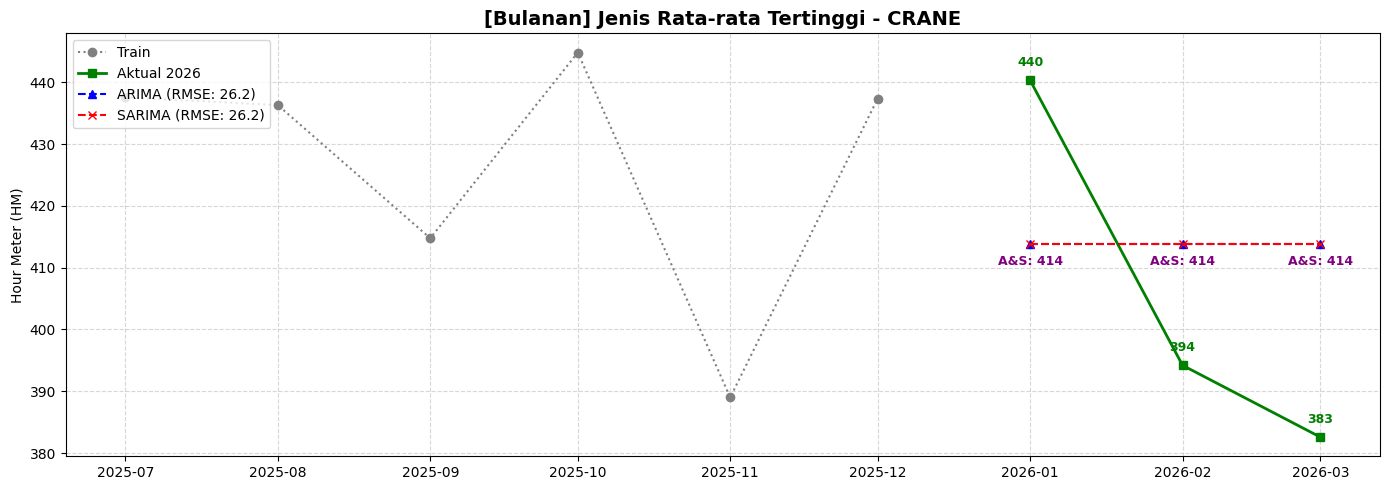

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,440.3,413.8,413.8
2026-02-01,394.2,413.8,413.8
2026-03-01,382.6,413.8,413.8




[Bulanan] Memproses Jenis Rata-rata Terendah: TOP LOADER


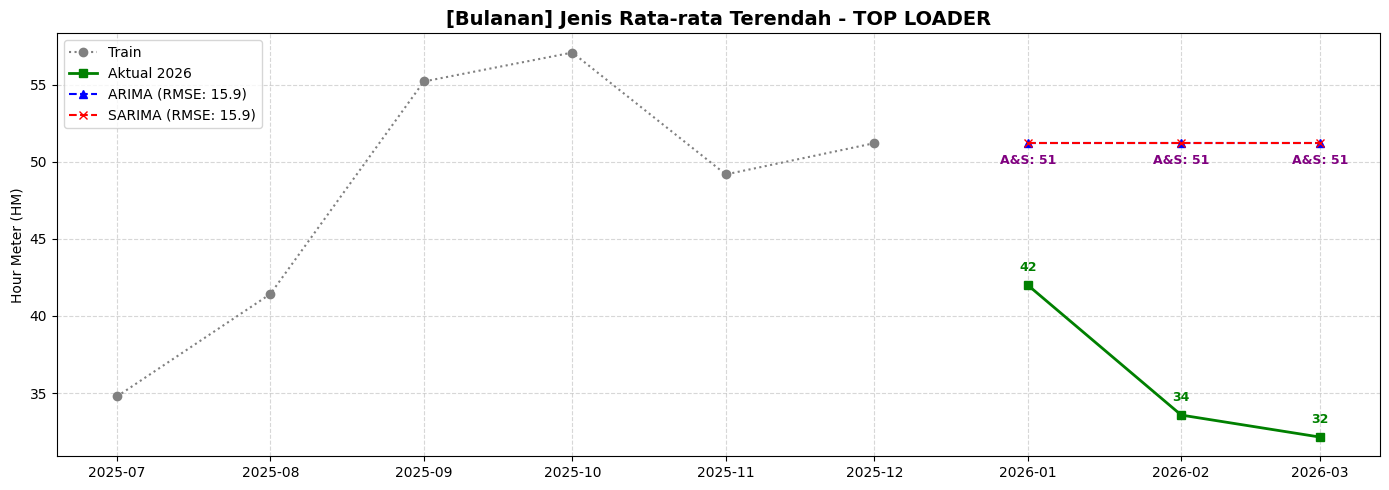

Rincian Tabel Prediksi Bulanan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-01,42.0,51.2,51.2
2026-02-01,33.6,51.2,51.2
2026-03-01,32.2,51.2,51.2





DATA MINGGUAN (m=52)
[Mingguan] Memproses Unit Tertinggi: RG02


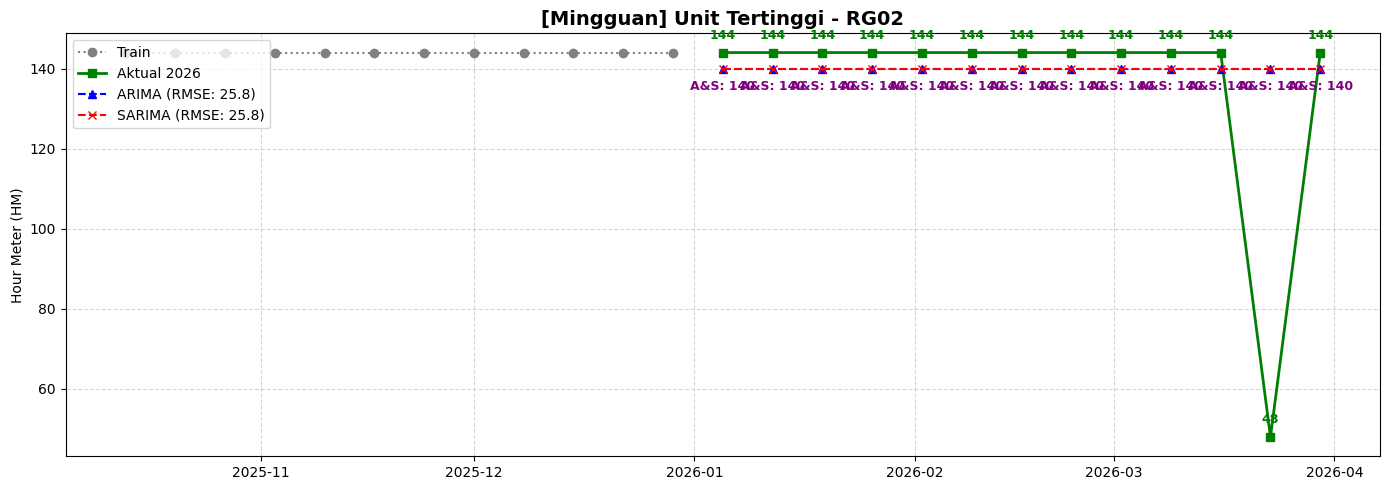

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,144.0,139.8,139.8
2026-01-12,144.0,139.8,139.8
2026-01-19,144.0,139.8,139.8
2026-01-26,144.0,139.8,139.8
2026-02-02,144.0,139.8,139.8
2026-02-09,144.0,139.8,139.8
2026-02-16,144.0,139.8,139.8
2026-02-23,144.0,139.8,139.8
2026-03-02,144.0,139.8,139.8
2026-03-09,144.0,139.8,139.8




[Mingguan] Memproses Unit Tertinggi: RG01


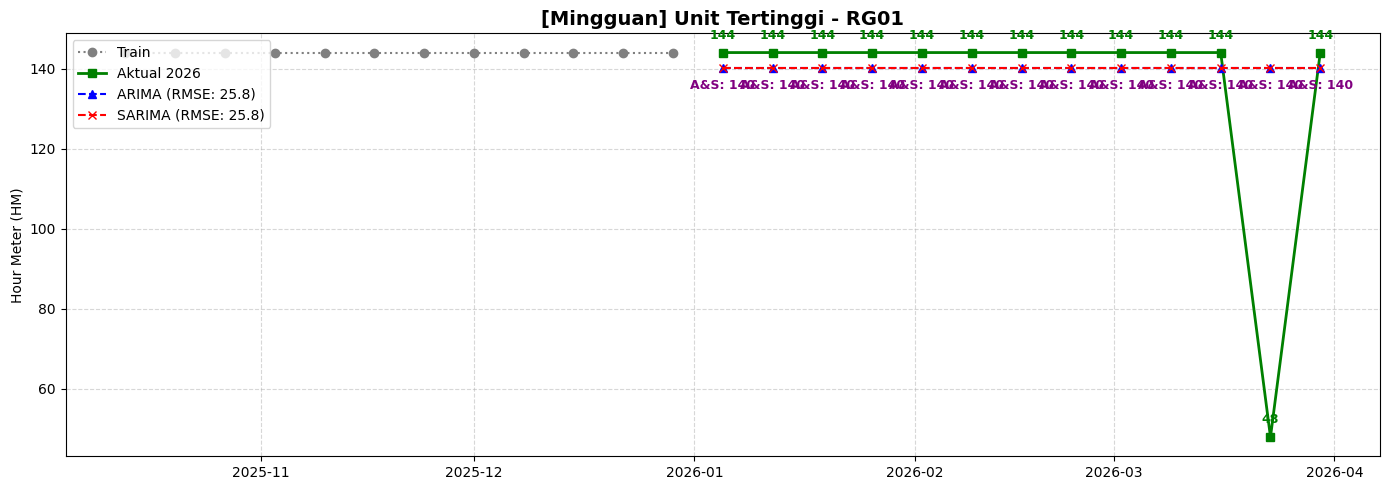

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,144.0,140.0,140.0
2026-01-12,144.0,140.0,140.0
2026-01-19,144.0,140.0,140.0
2026-01-26,144.0,140.0,140.0
2026-02-02,144.0,140.0,140.0
2026-02-09,144.0,140.0,140.0
2026-02-16,144.0,140.0,140.0
2026-02-23,144.0,140.0,140.0
2026-03-02,144.0,140.0,140.0
2026-03-09,144.0,140.0,140.0




[Mingguan] Memproses Unit Tertinggi: RG03


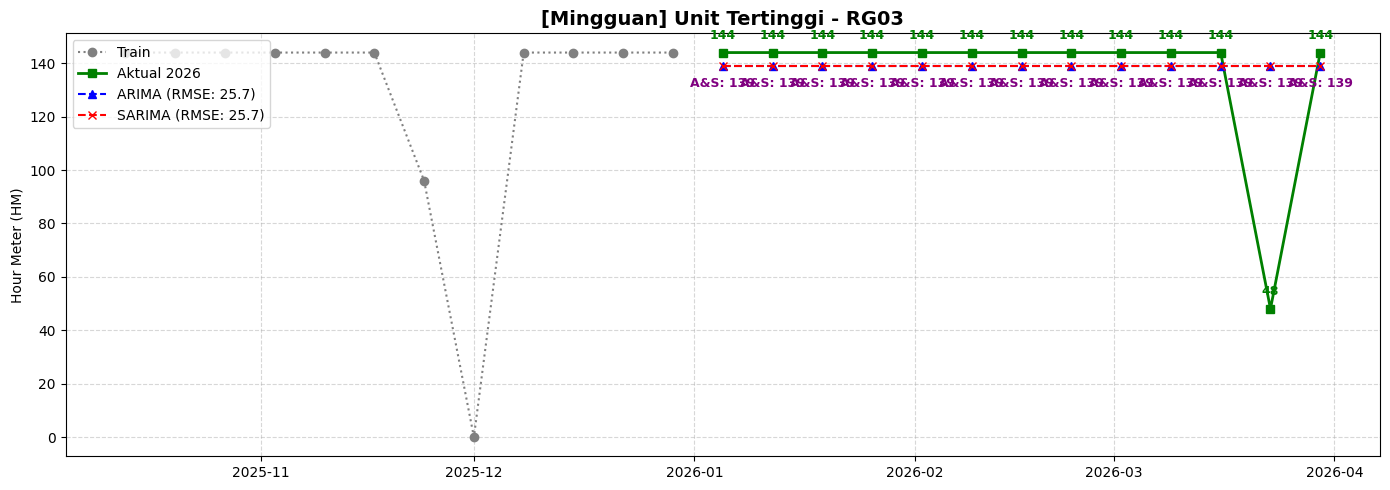

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,144.0,138.8,138.8
2026-01-12,144.0,138.8,138.8
2026-01-19,144.0,138.8,138.8
2026-01-26,144.0,138.8,138.8
2026-02-02,144.0,138.8,138.8
2026-02-09,144.0,138.8,138.8
2026-02-16,144.0,138.8,138.8
2026-02-23,144.0,138.8,138.8
2026-03-02,144.0,138.8,138.8
2026-03-09,144.0,138.8,138.8




[Mingguan] Memproses Unit Terendah: L 9103 NN EX. L 8781 LY


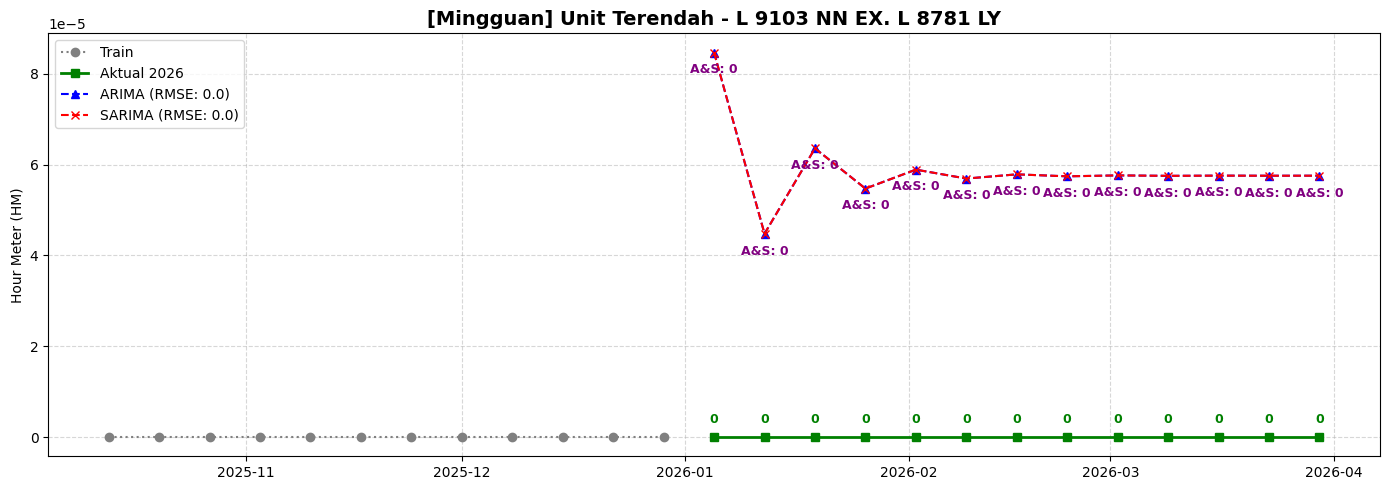

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,0.0,0.0,0.0
2026-01-12,0.0,0.0,0.0
2026-01-19,0.0,0.0,0.0
2026-01-26,0.0,0.0,0.0
2026-02-02,0.0,0.0,0.0
2026-02-09,0.0,0.0,0.0
2026-02-16,0.0,0.0,0.0
2026-02-23,0.0,0.0,0.0
2026-03-02,0.0,0.0,0.0
2026-03-09,0.0,0.0,0.0




[Mingguan] Memproses Unit Terendah: TOP LOADER MITS/CENDRAWASIH


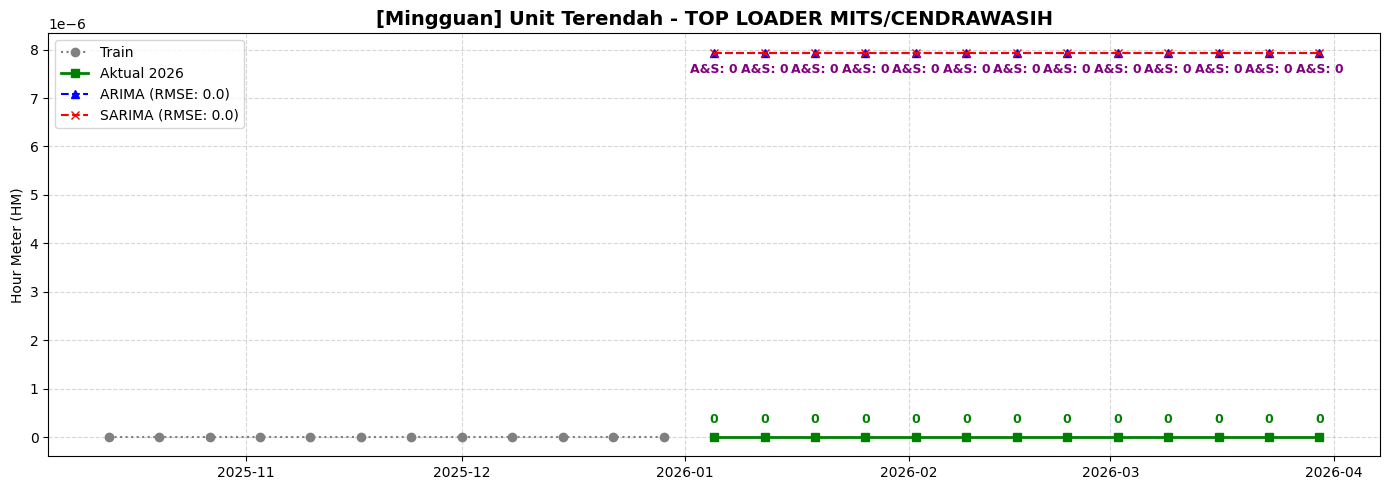

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,0.0,0.0,0.0
2026-01-12,0.0,0.0,0.0
2026-01-19,0.0,0.0,0.0
2026-01-26,0.0,0.0,0.0
2026-02-02,0.0,0.0,0.0
2026-02-09,0.0,0.0,0.0
2026-02-16,0.0,0.0,0.0
2026-02-23,0.0,0.0,0.0
2026-03-02,0.0,0.0,0.0
2026-03-09,0.0,0.0,0.0




[Mingguan] Memproses Unit Terendah: L 8604 UK (EX.L 9620 US)


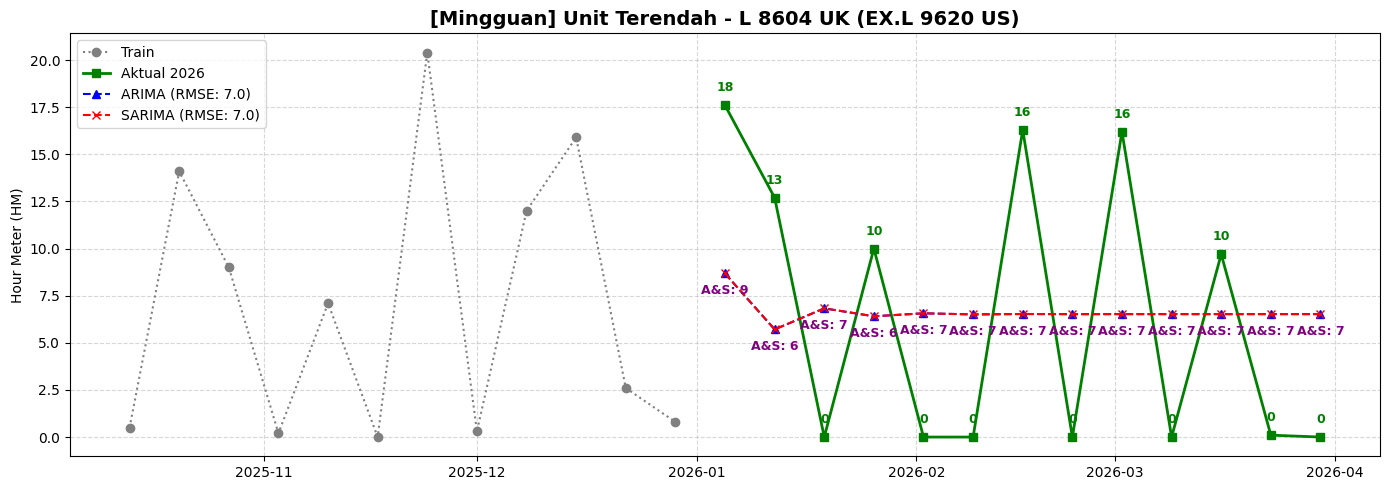

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,17.6,8.7,8.7
2026-01-12,12.7,5.7,5.7
2026-01-19,0.0,6.8,6.8
2026-01-26,10.0,6.4,6.4
2026-02-02,0.0,6.6,6.6
2026-02-09,0.0,6.5,6.5
2026-02-16,16.3,6.5,6.5
2026-02-23,0.0,6.5,6.5
2026-03-02,16.2,6.5,6.5
2026-03-09,0.0,6.5,6.5




[Mingguan] Memproses Jenis Rata-rata Tertinggi: CRANE


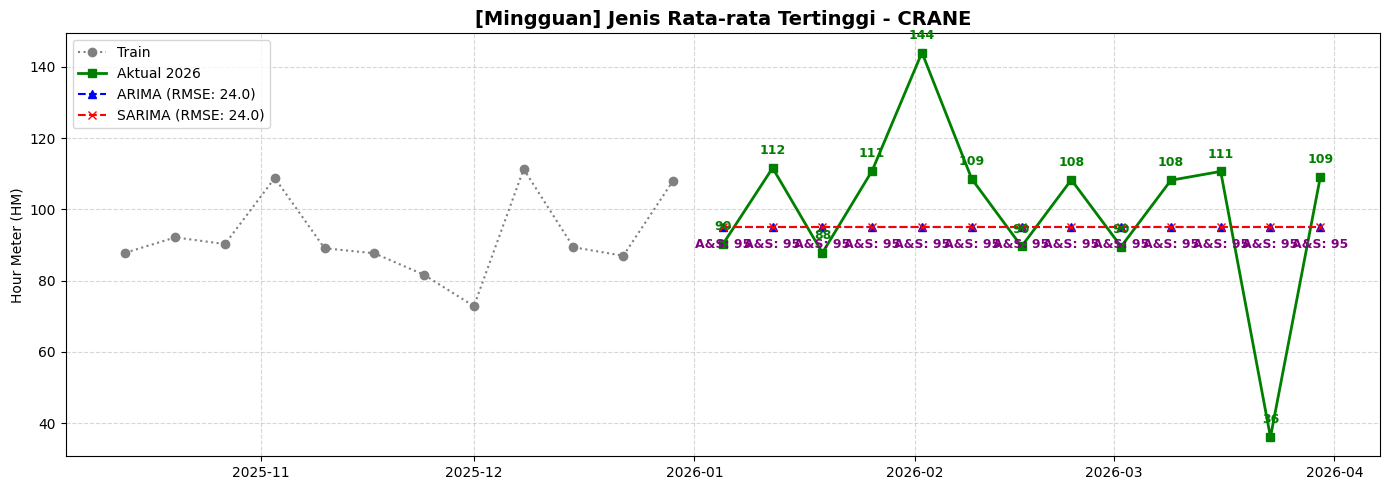

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,90.2,95.1,95.1
2026-01-12,111.6,95.1,95.1
2026-01-19,87.8,95.1,95.1
2026-01-26,110.9,95.1,95.1
2026-02-02,144.0,95.1,95.1
2026-02-09,108.5,95.1,95.1
2026-02-16,89.6,95.1,95.1
2026-02-23,108.3,95.1,95.1
2026-03-02,89.6,95.1,95.1
2026-03-09,108.2,95.1,95.1




[Mingguan] Memproses Jenis Rata-rata Terendah: TOP LOADER


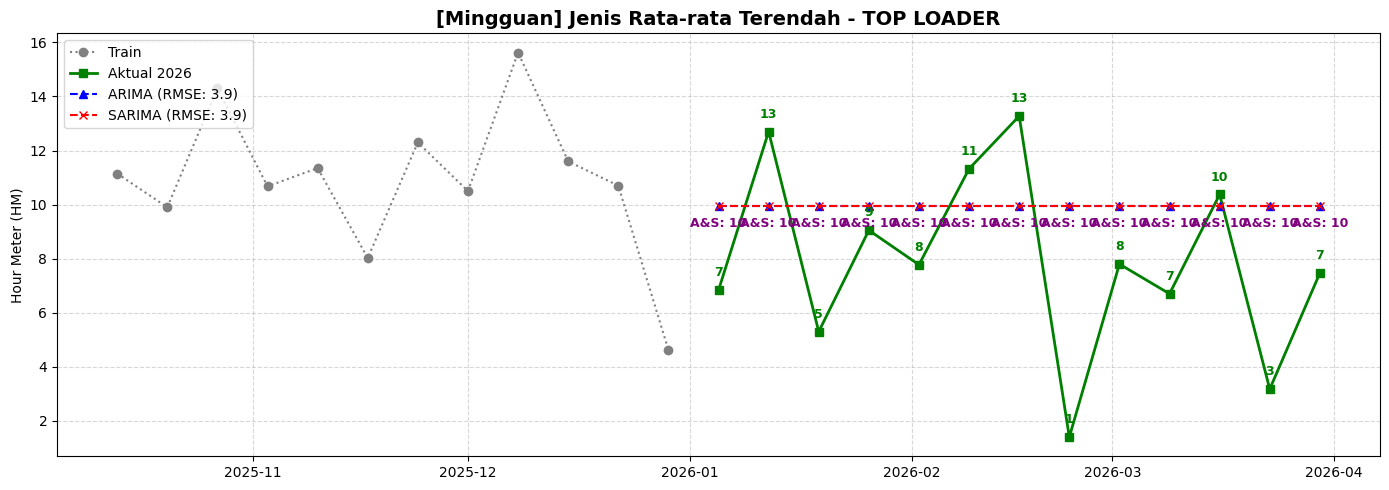

Rincian Tabel Prediksi Mingguan


,Aktual (HM),Prediksi_ARIMA,Prediksi_SARIMA
2026-01-05,6.8,10.0,10.0
2026-01-12,12.7,10.0,10.0
2026-01-19,5.3,10.0,10.0
2026-01-26,9.1,10.0,10.0
2026-02-02,7.8,10.0,10.0
2026-02-09,11.3,10.0,10.0
2026-02-16,13.3,10.0,10.0
2026-02-23,1.4,10.0,10.0
2026-03-02,7.8,10.0,10.0
2026-03-09,6.7,10.0,10.0


In [27]:
hasil_eksperimen = []

print("DATA BULANAN (m=12)")

# 1. Eksekusi Unit (Bulanan)
for unit in top_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='M', kategori_target="Unit Tertinggi")
    hasil_eksperimen.append(res)

for unit in bottom_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='M', kategori_target="Unit Terendah")
    hasil_eksperimen.append(res)

# 2. Eksekusi Jenis (Bulanan)
res = run_arima_vs_sarima(top_1_type, is_type=True, freq='M', kategori_target="Jenis Rata-rata Tertinggi")
hasil_eksperimen.append(res)

res = run_arima_vs_sarima(bottom_1_type, is_type=True, freq='M', kategori_target="Jenis Rata-rata Terendah")
hasil_eksperimen.append(res)


print("\nDATA MINGGUAN (m=52)")

# 3. Eksekusi Unit (Mingguan)
for unit in top_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='W', kategori_target="Unit Tertinggi")
    hasil_eksperimen.append(res)

for unit in bottom_3_units:
    res = run_arima_vs_sarima(unit, is_type=False, freq='W', kategori_target="Unit Terendah")
    hasil_eksperimen.append(res)

# 4. Eksekusi Jenis (Mingguan)
res = run_arima_vs_sarima(top_1_type, is_type=True, freq='W', kategori_target="Jenis Rata-rata Tertinggi")
hasil_eksperimen.append(res)

res = run_arima_vs_sarima(bottom_1_type, is_type=True, freq='W', kategori_target="Jenis Rata-rata Terendah")
hasil_eksperimen.append(res)

In [28]:
df_hasil = pd.DataFrame(hasil_eksperimen)

# Menghitung Persentase Error (Relative RMSE)
# Jika rata-rata aktual adalah 0, kita set persen ke 0 atau NaN untuk menghindari pembagian nol
df_hasil['Rel_RMSE_ARIMA (%)'] = np.where(df_hasil['Rata_Aktual_2026'] > 0, 
                                          (df_hasil['RMSE_ARIMA'] / df_hasil['Rata_Aktual_2026']) * 100, 0)
df_hasil['Rel_RMSE_SARIMA (%)'] = np.where(df_hasil['Rata_Aktual_2026'] > 0, 
                                           (df_hasil['RMSE_SARIMA'] / df_hasil['Rata_Aktual_2026']) * 100, 0)

def tentukan_pemenang(row):
    if pd.isna(row['RMSE_SARIMA']): return "ARIMA"
    return "SARIMA" if row['RMSE_SARIMA'] < row['RMSE_ARIMA'] else "ARIMA"

df_hasil['Model_Terbaik'] = df_hasil.apply(tentukan_pemenang, axis=1)

print("\nTABEL KESIMPULAN")
# Mengatur urutan kolom agar enak dibaca
cols = ['Kategori', 'Target', 'Frekuensi', 'Rata_Aktual_2026', 'RMSE_ARIMA', 'Rel_RMSE_ARIMA (%)', 'RMSE_SARIMA', 'Rel_RMSE_SARIMA (%)', 'Model_Terbaik']
display(df_hasil[cols].round(2))


TABEL KESIMPULAN


,Kategori,Target,Frekuensi,Rata_Aktual_2026,RMSE_ARIMA,Rel_RMSE_ARIMA (%),RMSE_SARIMA,Rel_RMSE_SARIMA (%),Model_Terbaik
0,Unit Tertinggi,RG02,Bulanan,664.00,50.83,7.66,50.83,7.66,ARIMA
1,Unit Tertinggi,RG01,Bulanan,664.00,51.94,7.82,50.69,7.63,SARIMA
2,Unit Tertinggi,RG03,Bulanan,664.00,47.54,7.16,47.54,7.16,ARIMA
3,Unit Terendah,L 9103 NN EX. L 8781 LY,Bulanan,0.00,0.00,0.00,0.00,0.00,ARIMA
4,Unit Terendah,TOP LOADER MITS/CENDRAWASIH,Bulanan,0.00,0.00,0.00,0.00,0.00,ARIMA
5,Unit Terendah,L 8604 UK (EX.L 9620 US),Bulanan,21.67,15.02,69.31,15.02,69.31,ARIMA
6,Jenis Rata-rata Tertinggi,CRANE,Bulanan,405.70,26.22,6.46,26.22,6.46,ARIMA
7,Jenis Rata-rata Terendah,TOP LOADER,Bulanan,35.91,15.90,44.27,15.90,44.27,ARIMA
8,Unit Tertinggi,RG02,Mingguan,136.62,25.78,18.87,25.78,18.87,ARIMA
9,Unit Tertinggi,RG01,Mingguan,136.62,25.81,18.89,25.81,18.89,ARIMA
